# Phase 3 — Baseline Models

**Goal:** establish naive, linear regression, and ARIMA baselines for
next-day `Adj Close` prediction on all 40 stocks, using the exact same
chronological test split and metrics the LSTM (Phase 4) will be judged
against. The LSTM's value is only meaningful relative to these baselines.

### Common information cutoff (fairness across models)
Every model predicts `Adj Close` at date `t+1` using only information
available through date `t` ("today"):

- **Naive** — tomorrow's close = today's close.
- **Linear regression** — today's *engineered* features (never raw OHLCV) →
  tomorrow's close.
- **ARIMA** — fit on pre-test history, then walk forward one step at a time:
  append each test date's *already-realised* actual close to the model state,
  forecast one day ahead. This avoids the compounding error of a single
  static multi-step forecast, and keeps ARIMA's cutoff identical to the other
  two models' (see `src/baselines.py` docstring for the full rationale).

### ARIMA convergence
ARIMA can fail to converge on some series. We try a list of fallback orders
per stock and log — explicitly, per stock — any that still fail and are
excluded from the ARIMA comparison.

> Run top-to-bottom with no manual intervention. Assumes Phase 1 (`data/raw/`)
> and Phase 2 (`data/processed/`) have already been run.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_loader import load_universe, flat_tickers, ticker_to_sector
from src.features import FEATURE_COLUMNS
from src.scaling import chronological_split, scale_features
from src.baselines import naive_forecast, linear_regression_forecast, arima_forecast
from src.evaluate import compute_metrics

PROCESSED_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", context="notebook")

# ARIMA orders to try, in order, per stock. Not grid-searched per the spec —
# ARIMA is a classical reference point, not the model under study.
ARIMA_ORDERS = [(5, 1, 0), (2, 1, 0), (1, 1, 0), (1, 1, 1)]

print("Repo root:", ROOT)

Repo root: /Users/pranav/Documents/GitHub/stock-lstm-forecast


## 1. Load universe and per-stock engineered data

Reads the universe locked in Phase 1 and the engineered features saved in
Phase 2 — this notebook does not recompute either.

In [2]:
universe = load_universe()
tickers = flat_tickers(universe)
tk2sec = ticker_to_sector(universe)
print(f"{len(tickers)} tickers loaded.")

40 tickers loaded.


## 2. Per-stock pipeline

For each stock: build the next-day-close target, apply the Phase 2
chronological 70/15/15 split and train-only-fit scaler, then run all three
baselines and score them with `compute_metrics` (RMSE, MAE, MAPE, directional
accuracy — all defined against the same "today → tomorrow" cutoff).

**Target construction note:** `target_next_close = Adj Close.shift(-1)` is
computed on the *full* engineered series before splitting, so the last row of
train correctly targets the first row of val (and likewise train/val → test)
rather than being dropped at each split boundary. Only the very last date in
the whole history is dropped (it has no "tomorrow" to target) — one row out
of ~1187, immaterial to the split proportions already established in Phase 2.

In [3]:
def build_target(feats: pd.DataFrame) -> pd.DataFrame:
    out = feats.copy()
    out["target_next_close"] = out["Adj Close"].shift(-1)
    return out.dropna(subset=["target_next_close"])


def run_arima_with_fallback(history, test_actuals, orders=ARIMA_ORDERS):
    """Try each order in turn; return (predictions, order_used, error_log)."""
    errors = []
    for order in orders:
        try:
            preds = arima_forecast(history, test_actuals, order=order)
            return preds, order, errors
        except Exception as exc:  # noqa: BLE001 — log and try the next order
            errors.append(f"order={order}: {type(exc).__name__}: {exc}")
    return None, None, errors

In [4]:
results = []
arima_failures = []
predictions_store = {}  # ticker -> dict of {"dates":..., "actual":..., "naive":..., "linreg":..., "arima":... or None}

for i, tk in enumerate(tickers, 1):
    path = PROCESSED_DIR / f"{tk.replace('.', '_')}.csv"
    feats = pd.read_csv(path, index_col="Date", parse_dates=True)
    feats = build_target(feats)

    train, val, test = chronological_split(feats, train_frac=0.70, val_frac=0.15)
    train_s, val_s, test_s, scaler = scale_features(train, val, test, FEATURE_COLUMNS)

    y_train = train["target_next_close"]
    y_test = test["target_next_close"]
    y_prev_test = test["Adj Close"]  # "today's" actual close for each test row

    # --- Naive ---
    naive_pred = naive_forecast(test["Adj Close"])
    naive_metrics = compute_metrics(y_test, naive_pred, y_prev_test)

    # --- Linear regression ---
    lr_pred = linear_regression_forecast(
        train_s[FEATURE_COLUMNS], y_train, test_s[FEATURE_COLUMNS]
    )
    lr_pred = pd.Series(lr_pred, index=test.index)
    lr_metrics = compute_metrics(y_test, lr_pred, y_prev_test)

    # --- ARIMA (with fallback orders, graceful failure) ---
    history = pd.concat([train["Adj Close"], val["Adj Close"]])
    arima_pred, order_used, arima_errors = run_arima_with_fallback(history, test["Adj Close"])
    if arima_pred is not None:
        arima_metrics = compute_metrics(y_test, arima_pred, y_prev_test)
    else:
        arima_metrics = {"rmse": np.nan, "mae": np.nan, "mape": np.nan,
                          "directional_accuracy": np.nan, "n_obs": 0}
        arima_failures.append({"ticker": tk, "sector": tk2sec[tk], "errors": arima_errors})

    results.append({
        "ticker": tk, "sector": tk2sec[tk],
        "naive_RMSE": naive_metrics["rmse"], "naive_MAE": naive_metrics["mae"],
        "naive_MAPE": naive_metrics["mape"], "naive_DirAcc": naive_metrics["directional_accuracy"],
        "linreg_RMSE": lr_metrics["rmse"], "linreg_MAE": lr_metrics["mae"],
        "linreg_MAPE": lr_metrics["mape"], "linreg_DirAcc": lr_metrics["directional_accuracy"],
        "arima_RMSE": arima_metrics["rmse"], "arima_MAE": arima_metrics["mae"],
        "arima_MAPE": arima_metrics["mape"], "arima_DirAcc": arima_metrics["directional_accuracy"],
        "arima_order": order_used,
    })

    predictions_store[tk] = {
        "dates": test.index, "actual": y_test.values,
        "naive": naive_pred.values, "linreg": lr_pred.values,
        "arima": arima_pred.values if arima_pred is not None else None,
    }

    status = f"ARIMA order={order_used}" if arima_pred is not None else "ARIMA FAILED (all orders)"
    print(f"[{i:>2}/{len(tickers)}] {tk:<16} naive_RMSE={naive_metrics['rmse']:.2f}  "
          f"linreg_RMSE={lr_metrics['rmse']:.2f}  {status}")

print(f"\nDone: {len(results)} stocks processed, {len(arima_failures)} ARIMA failure(s).")

[ 1/40] TCS.NS           naive_RMSE=45.90  linreg_RMSE=50.50  ARIMA order=(5, 1, 0)


[ 2/40] INFY.NS          naive_RMSE=25.32  linreg_RMSE=26.92  ARIMA order=(5, 1, 0)


[ 3/40] HCLTECH.NS       naive_RMSE=25.33  linreg_RMSE=28.56  ARIMA order=(5, 1, 0)


[ 4/40] WIPRO.NS         naive_RMSE=3.65  linreg_RMSE=3.78  ARIMA order=(5, 1, 0)


[ 5/40] TECHM.NS         naive_RMSE=26.89  linreg_RMSE=28.94  ARIMA order=(5, 1, 0)


...

[36/40] MARICO.NS        naive_RMSE=8.88  linreg_RMSE=9.54  ARIMA order=(5, 1, 0)


[37/40] GODREJCP.NS      naive_RMSE=17.52  linreg_RMSE=19.60  ARIMA order=(5, 1, 0)


[38/40] TATACONSUM.NS    naive_RMSE=16.99  linreg_RMSE=17.52  ARIMA order=(5, 1, 0)


[39/40] DABUR.NS         naive_RMSE=7.12  linreg_RMSE=8.10  ARIMA order=(5, 1, 0)


[40/40] COLPAL.NS        naive_RMSE=31.58  linreg_RMSE=34.94  ARIMA order=(5, 1, 0)

Done: 40 stocks processed, 0 ARIMA failure(s).


## 3. ARIMA failures — documented, not hidden

Any stock where **all** fallback orders failed to fit is excluded from the
ARIMA comparison (its `arima_*` columns are `NaN` in the results table) and
listed here with the underlying error for each attempted order.

In [5]:
if arima_failures:
    print(f"{len(arima_failures)} stock(s) excluded from ARIMA comparison:\n")
    for f in arima_failures:
        print(f"  {f['ticker']} ({f['sector']}):")
        for e in f["errors"]:
            print(f"      {e}")
else:
    print("No ARIMA failures — all 40 stocks produced a valid ARIMA forecast "
          "with at least one of the fallback orders.")

No ARIMA failures — all 40 stocks produced a valid ARIMA forecast with at least one of the fallback orders.


## 4. Results table — rows = stocks, columns = model × metric

Saved to `results/baseline_metrics.csv`.

In [6]:
results_df = pd.DataFrame(results).set_index("ticker")
results_df.to_csv(RESULTS_DIR / "baseline_metrics.csv")
print(f"Saved {RESULTS_DIR / 'baseline_metrics.csv'}  ({len(results_df)} rows)")
results_df.round(3)

Saved /Users/pranav/Documents/GitHub/stock-lstm-forecast/results/baseline_metrics.csv  (40 rows)


,sector,naive_RMSE,naive_MAE,naive_MAPE,naive_DirAcc,linreg_RMSE,linreg_MAE,linreg_MAPE,linreg_DirAcc,arima_RMSE,arima_MAE,arima_MAPE,arima_DirAcc,arima_order
ticker,,,,,,,,,,,,,,
TCS.NS,Information Technology,45.895,31.691,1.225,2.235,50.499,36.479,1.417,53.073,46.100,32.036,1.237,45.251,"(5, 1, 0)"
INFY.NS,Information Technology,25.315,17.727,1.365,2.235,26.916,19.266,1.493,47.486,25.416,17.891,1.378,48.603,"(5, 1, 0)"
HCLTECH.NS,Information Technology,25.331,17.180,1.263,2.235,28.558,20.692,1.542,45.810,25.545,17.409,1.281,42.458,"(5, 1, 0)"
WIPRO.NS,Information Technology,3.649,2.504,1.170,2.235,3.784,2.786,1.316,52.514,3.648,2.505,1.171,51.955,"(5, 1, 0)"
TECHM.NS,Information Technology,26.893,19.615,1.358,3.352,28.936,21.540,1.493,46.369,27.033,19.857,1.375,48.045,"(5, 1, 0)"
OFSS.NS,Information Technology,169.393,124.811,1.530,2.235,180.153,134.160,1.638,47.486,168.286,125.192,1.537,50.838,"(5, 1, 0)"
PERSISTENT.NS,Information Technology,118.887,85.753,1.606,2.793,137.745,103.103,1.959,48.045,121.154,87.327,1.636,50.838,"(5, 1, 0)"
COFORGE.NS,Information Technology,35.883,26.789,1.838,2.235,41.325,32.039,2.202,50.279,36.124,27.169,1.860,46.369,"(5, 1, 0)"
MPHASIS.NS,Information Technology,44.000,33.725,1.414,2.235,45.420,35.706,1.498,51.397,43.907,33.719,1.415,54.190,"(5, 1, 0)"


### Persist per-stock predictions for the Streamlit app (Phase 5)

The deployed app reads precomputed predictions rather than retraining or
re-fetching data live (keeps load times fast, avoids Yahoo rate limits). Save
each stock's test-period `(date, actual, naive, linreg, arima)` series to
`results/predictions/<TICKER>.csv` — the LSTM column is appended in Phase 4's
notebook once it's trained.

In [7]:
PRED_DIR = RESULTS_DIR / "predictions"
PRED_DIR.mkdir(parents=True, exist_ok=True)

for tk, d in predictions_store.items():
    pred_df = pd.DataFrame({
        "date": d["dates"],
        "actual": d["actual"],
        "naive": d["naive"],
        "linreg": d["linreg"],
        "arima": d["arima"] if d["arima"] is not None else np.nan,
    })
    pred_df.to_csv(PRED_DIR / f"{tk.replace('.', '_')}.csv", index=False)

print(f"Saved {len(predictions_store)} per-stock prediction files to {PRED_DIR}")

Saved 40 per-stock prediction files to /Users/pranav/Documents/GitHub/stock-lstm-forecast/results/predictions


### Sector-level summary

Mean RMSE and directional accuracy per model, aggregated by sector (ARIMA
excludes any failed stocks from its sector mean).

In [8]:
summary_cols = ["naive_RMSE", "linreg_RMSE", "arima_RMSE",
                 "naive_DirAcc", "linreg_DirAcc", "arima_DirAcc"]
sector_summary = results_df.groupby("sector")[summary_cols].mean().round(2)
sector_summary

,naive_RMSE,linreg_RMSE,arima_RMSE,naive_DirAcc,linreg_DirAcc,arima_DirAcc
sector,,,,,,
Banking & Financial Services,17.05,18.76,17.03,2.74,48.52,51.03
Energy,11.04,12.61,11.13,2.63,48.99,50.89
FMCG,21.34,23.28,21.40,2.46,47.49,49.05
Information Technology,58.34,63.72,58.68,2.46,49.94,48.83


### Which model wins, per stock (lowest RMSE)

Since price scales vary hugely across stocks (a few rupees vs several
thousand), RMSE is only comparable *within* a stock, not across stocks — this
"best model per stock" view is still meaningful even though the aggregate
sector RMSE table above is dominated by high-priced names.

In [9]:
rmse_cols = ["naive_RMSE", "linreg_RMSE", "arima_RMSE"]
best_model = results_df[rmse_cols].idxmin(axis=1).str.replace("_RMSE", "", regex=False)
print("Best model (lowest RMSE) — win counts across 40 stocks:")
print(best_model.value_counts())
print("\nBest model by sector:")
print(pd.crosstab(results_df["sector"], best_model))

Best model (lowest RMSE) — win counts across 40 stocks:
naive    29
arima    11
Name: count, dtype: int64

Best model by sector:
col_0                         arima  naive
sector                                    
Banking & Financial Services      6      4
Energy                            0     10
FMCG                              2      8
Information Technology            3      7


## 5. Predicted-vs-actual plots — 3 representative stocks

To compare fairly across stocks of very different price levels, we rank by
**relative RMSE** (`best-model RMSE / mean test-period price`) and pick:
- the stock where the best baseline did **best** (lowest relative RMSE),
- the stock where it did **worst** (highest relative RMSE),
- a stock near the **median** (average case).

In [10]:
results_df["best_rmse"] = results_df[rmse_cols].min(axis=1)
results_df["mean_test_price"] = [
    np.mean(predictions_store[tk]["actual"]) for tk in results_df.index
]
results_df["relative_rmse_pct"] = results_df["best_rmse"] / results_df["mean_test_price"] * 100

ranked = results_df["relative_rmse_pct"].dropna().sort_values()
best_stock = ranked.index[0]
worst_stock = ranked.index[-1]
median_stock = ranked.index[len(ranked) // 2]

print(f"Best case  (lowest relative RMSE):  {best_stock}   "
      f"({ranked.loc[best_stock]:.2f}%)")
print(f"Average case (median relative RMSE): {median_stock}   "
      f"({ranked.loc[median_stock]:.2f}%)")
print(f"Worst case (highest relative RMSE): {worst_stock}   "
      f"({ranked.loc[worst_stock]:.2f}%)")

Best case  (lowest relative RMSE):  MARICO.NS   (1.15%)
Average case (median relative RMSE): ONGC.NS   (1.67%)
Worst case (highest relative RMSE): ADANIGREEN.NS   (2.63%)


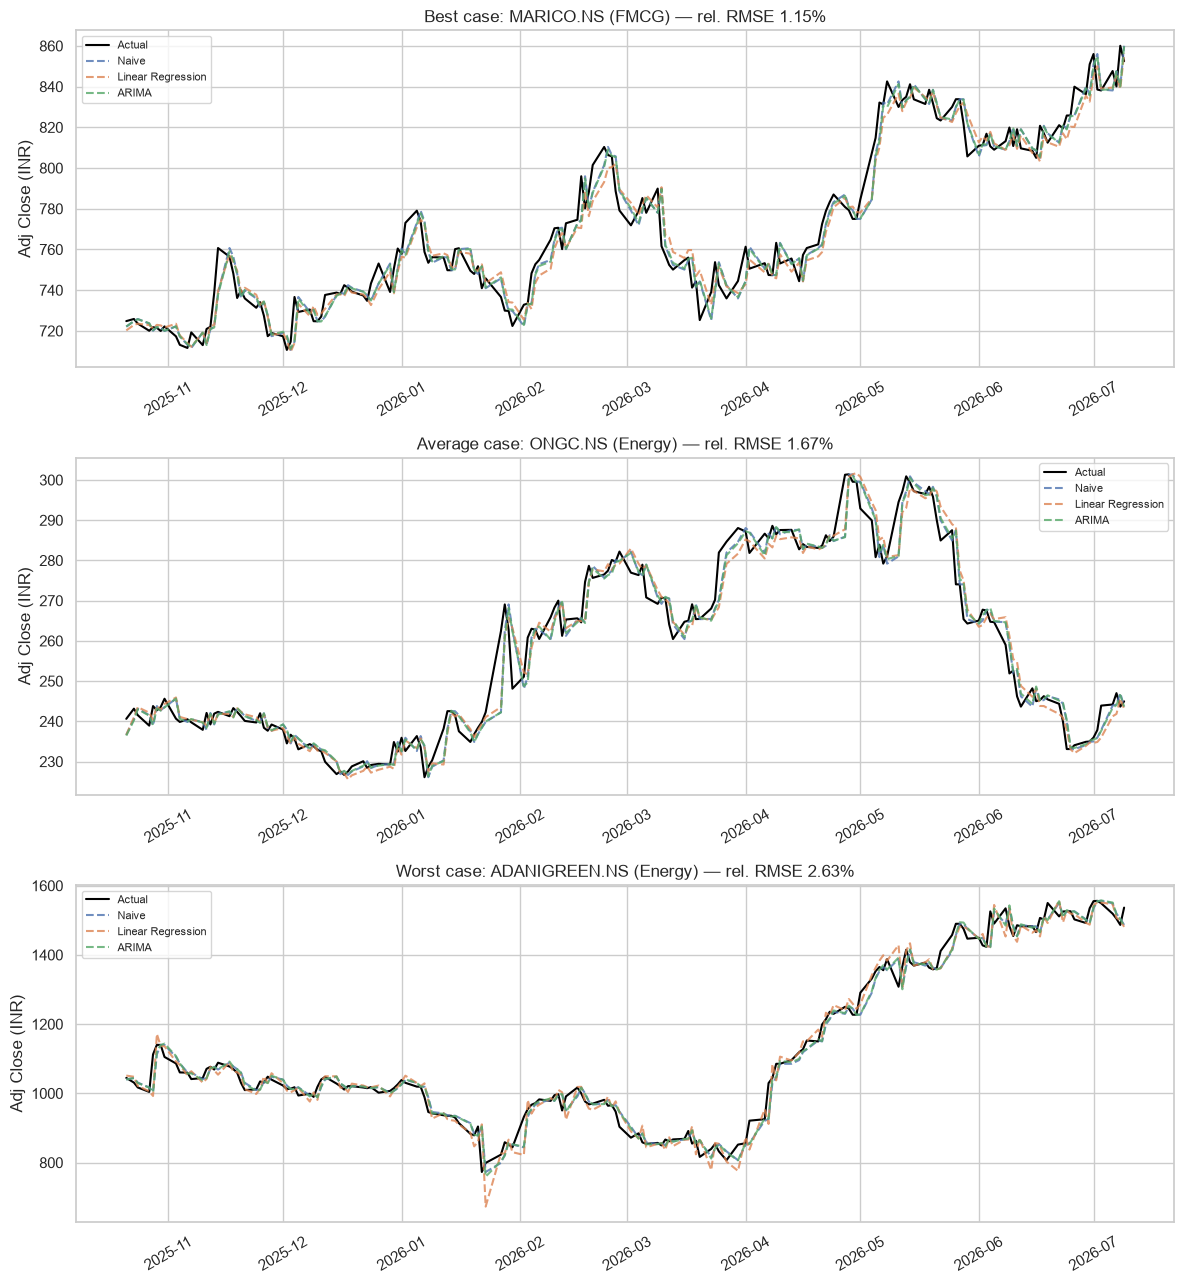

In [11]:
def plot_predictions(ticker, label, ax):
    d = predictions_store[ticker]
    ax.plot(d["dates"], d["actual"], label="Actual", color="black", linewidth=1.5)
    ax.plot(d["dates"], d["naive"], label="Naive", linestyle="--", alpha=0.8)
    ax.plot(d["dates"], d["linreg"], label="Linear Regression", linestyle="--", alpha=0.8)
    if d["arima"] is not None:
        ax.plot(d["dates"], d["arima"], label="ARIMA", linestyle="--", alpha=0.8)
    ax.set_title(f"{label}: {ticker} ({tk2sec[ticker]}) — "
                 f"rel. RMSE {results_df.loc[ticker, 'relative_rmse_pct']:.2f}%")
    ax.set_ylabel("Adj Close (INR)")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

fig, axes = plt.subplots(3, 1, figsize=(12, 13))
plot_predictions(best_stock, "Best case", axes[0])
plot_predictions(median_stock, "Average case", axes[1])
plot_predictions(worst_stock, "Worst case", axes[2])
plt.tight_layout()
plt.savefig(PLOTS_DIR / "baselines_pred_vs_actual.png", dpi=110)
plt.show()

## Phase 3 takeaways

- **Naive is a genuinely strong baseline** on daily close prediction — as
  expected for a near-random-walk series, "tomorrow = today" produces low
  RMSE simply because day-to-day price changes are small relative to price
  level. Its **directional accuracy is close to 0%** by construction (its
  predicted change is always exactly zero, so it essentially never matches a
  nonzero actual direction) — a look at the win-count and sector tables above
  shows exactly how often naive's low RMSE coexists with no directional skill
  at all. This gap between "low RMSE" and "no directional skill" is itself
  the key baseline finding to carry into the LSTM comparison.
- **Linear regression and ARIMA** are evaluated on the same next-day cutoff;
  see the results table for which wins where.
- **ARIMA failures** (if any) are listed explicitly above rather than
  silently dropped from the universe.

**Next (Phase 4):** LSTM sequence model, evaluated with the same
`compute_metrics` for direct comparability, and a combined
`results/final_comparison.csv`. The critical question: does the LSTM's RMSE
and/or directional accuracy meaningfully beat naive/linreg/ARIMA, or does it
just match naive's "reasonable RMSE, ~no directional skill" pattern with
extra complexity for nothing?